# Analyse exploratoire des données brutes (RAW Layer)

Dans cette première étape, nous analysons le dataset brut provenant de Kaggle sans appliquer de transformation.

Objectifs :

- Comprendre la structure des données
- Identifier les valeurs manquantes
- Détecter d’éventuels doublons
- Étudier la distribution des variables importantes
- Préparer les étapes futures du pipeline (Silver → Gold)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

df = pd.read_csv("../data/raw/job_market.csv")

# Aperçu général des données

Nous observons les premières lignes afin de comprendre la structure globale du dataset.

In [2]:
df.head()

,job_title,company,location,job_type,category,salary_min,salary_max,experience_required,publication_date,skills,education_level,company_size,benefits
0,Engineering Manager,DataInc,"San Francisco, CA",Remote,Technology,151082,291345,4.0,11/27/2025,"AWS, Agile, Machine Learning, Kubernetes, Mong...",Master's Degree,1-50 employees,"Health Insurance, 401(k), Unlimited PTO"
1,Engineering Manager,EnterpriseHub,"New York, NY",Remote,Technology,156891,280075,3.0,11/27/2025,"Java, Agile, Git, SQL, Ruby, Go",PhD,1-50 employees,"Dental, Vision, Annual Bonus"
2,Engineering Manager,StartupXYZ,"Seattle, WA",Part-time,Technology,152134,280310,4.0,11/27/2025,"AWS, Python, Kubernetes, Git",Associate Degree,1000+ employees,"Stock Options, Remote Work Stipend"
3,Lead Engineer,WebDynamics,"Seattle, WA",Full-time,Technology,151918,253988,7.0,11/27/2025,"Agile, Git, Docker, REST APIs, TypeScript",PhD,1000+ employees,"Health Insurance, 401(k), Unlimited PTO"
4,Senior Software Engineer,DigitalWorks,"San Francisco, CA",Full-time,Technology,148141,252584,9.0,11/27/2025,"Agile, Ruby, Docker, Git, JavaScript",High School,1000+ employees,"Health Insurance, 401(k), Unlimited PTO"


# Dimensions du dataset



In [3]:
print("Nombre de lignes et colonnes :", df.shape)

Nombre de lignes et colonnes : (250, 13)


# Structure des variables

Nous analysons :

- le type de chaque variable
- le nombre de valeurs non nulles

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_title            250 non-null    str    
 1   company              250 non-null    str    
 2   location             250 non-null    str    
 3   job_type             221 non-null    str    
 4   category             230 non-null    str    
 5   salary_min           250 non-null    int64  
 6   salary_max           250 non-null    int64  
 7   experience_required  207 non-null    float64
 8   publication_date     250 non-null    str    
 9   skills               200 non-null    str    
 10  education_level      250 non-null    str    
 11  company_size         250 non-null    str    
 12  benefits             250 non-null    str    
dtypes: float64(1), int64(2), str(10)
memory usage: 25.5 KB


# Analyse des valeurs manquantes

Avant toute transformation, il est nécessaire d’identifier les colonnes contenant des données absentes.

In [5]:
missing_values = df.isnull().sum()

print(missing_values)

job_title               0
company                 0
location                0
job_type               29
category               20
salary_min              0
salary_max              0
experience_required    43
publication_date        0
skills                 50
education_level         0
company_size            0
benefits                0
dtype: int64


# Pourcentage de données manquantes

Cette analyse permet d’évaluer la qualité du dataset brut.

In [6]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

job_title               0.0
company                 0.0
location                0.0
job_type               11.6
category                8.0
salary_min              0.0
salary_max              0.0
experience_required    17.2
publication_date        0.0
skills                 20.0
education_level         0.0
company_size            0.0
benefits                0.0
dtype: float64


# Visualisation des valeurs manquantes

Représentation graphique du pourcentage de données manquantes par colonne.

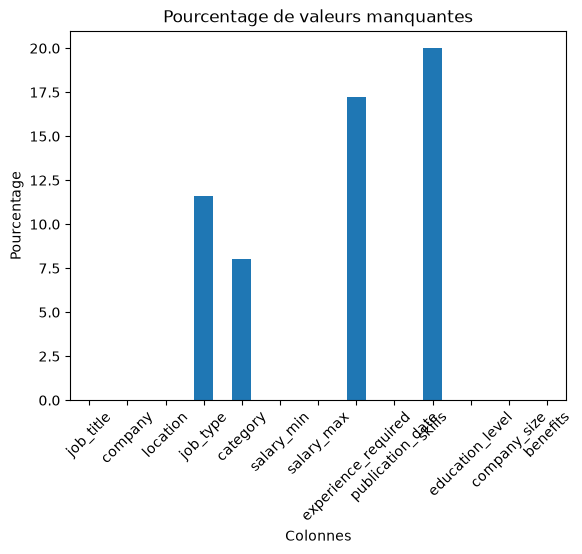

In [7]:
missing_percentage.plot(kind="bar")

plt.title("Pourcentage de valeurs manquantes")

plt.xlabel("Colonnes")

plt.ylabel("Pourcentage")

plt.xticks(rotation=45)

plt.show()

# Détection des doublons

Nous vérifions si certaines lignes apparaissent plusieurs fois dans le dataset.

In [8]:
duplicates = df.duplicated().sum()

print("Nombre de doublons :", duplicates)

Nombre de doublons : 0


# Distribution des catégories de métiers

Cette étape permet d’identifier les catégories de postes les plus représentées.

In [9]:
print(df["category"].value_counts())

category
Technology                     200
Remote                          11
Marketing and Communication      6
Software Development             4
Social Media Manager             2
Recruitment and Selection        1
SAP/ERP Consulting               1
Helpdesk                         1
Media Planning                   1
Finance                          1
Process Engineering              1
HR                               1
Name: count, dtype: int64


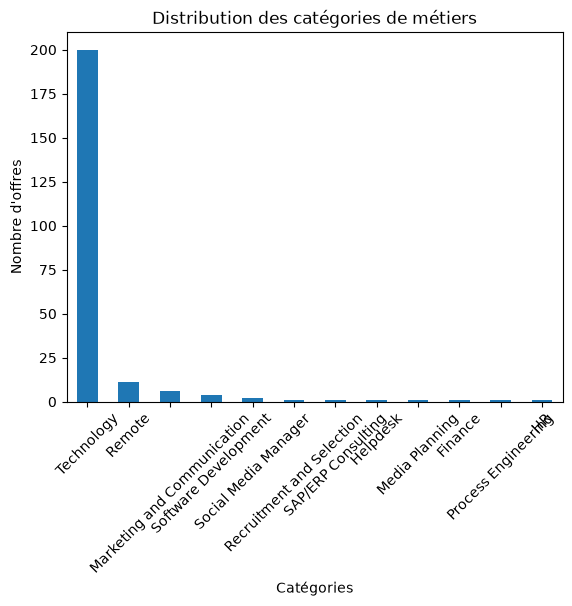

In [10]:
df["category"].value_counts().plot(kind="bar")

plt.title("Distribution des catégories de métiers")

plt.xlabel("Catégories")

plt.ylabel("Nombre d'offres")

plt.xticks(rotation=45)

plt.show()

# Analyse des salaires

Nous analysons :

- salaire minimum
- salaire maximum
- distribution des rémunérations

In [11]:
print(df[["salary_min", "salary_max"]].describe())

          salary_min     salary_max
count     250.000000     250.000000
mean    89067.900000  155685.424000
std     23183.593666   42842.170809
min     45000.000000   70000.000000
25%     71880.500000  130631.750000
50%     88136.000000  149535.000000
75%    105755.250000  186913.500000
max    156891.000000  291345.000000


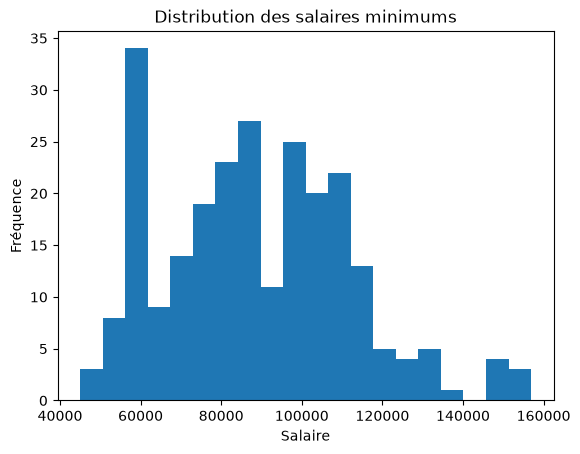

In [12]:
df["salary_min"].plot(kind="hist", bins=20)

plt.title("Distribution des salaires minimums")

plt.xlabel("Salaire")

plt.ylabel("Fréquence")

plt.show()

# Analyse de la colonne Skills

Cette colonne constitue le cœur du projet AISCA car elle servira à construire le référentiel de compétences.

In [13]:
all_skills = []

for skill_list in df["skills"].dropna():
    
    skills = skill_list.split(",")

    for skill in skills:
        all_skills.append(skill.strip())

# Extraction des compétences uniques

Nous extrayons l’ensemble des compétences présentes dans le dataset.

In [14]:
unique_skills = sorted(list(set(all_skills)))

print("Nombre de compétences uniques :", len(unique_skills))

print(unique_skills)

Nombre de compétences uniques : 19
['AWS', 'Agile', 'CI/CD', 'Docker', 'Git', 'Go', 'Java', 'JavaScript', 'Kubernetes', 'Machine Learning', 'MongoDB', 'Node.js', 'Python', 'REST APIs', 'React', 'Ruby', 'SQL', 'TensorFlow', 'TypeScript']


# Compétences les plus demandées

Cette analyse permet d’identifier les compétences techniques les plus fréquentes sur le marché.

In [15]:
skill_counts = Counter(all_skills)

print(skill_counts.most_common(20))

[('Machine Learning', 71), ('Python', 67), ('Go', 60), ('Git', 59), ('Docker', 58), ('Agile', 57), ('AWS', 56), ('CI/CD', 56), ('Ruby', 55), ('TypeScript', 55), ('JavaScript', 54), ('REST APIs', 53), ('Node.js', 52), ('React', 52), ('SQL', 51), ('Kubernetes', 48), ('Java', 47), ('TensorFlow', 43), ('MongoDB', 38)]


# Top 15 des compétences les plus fréquentes

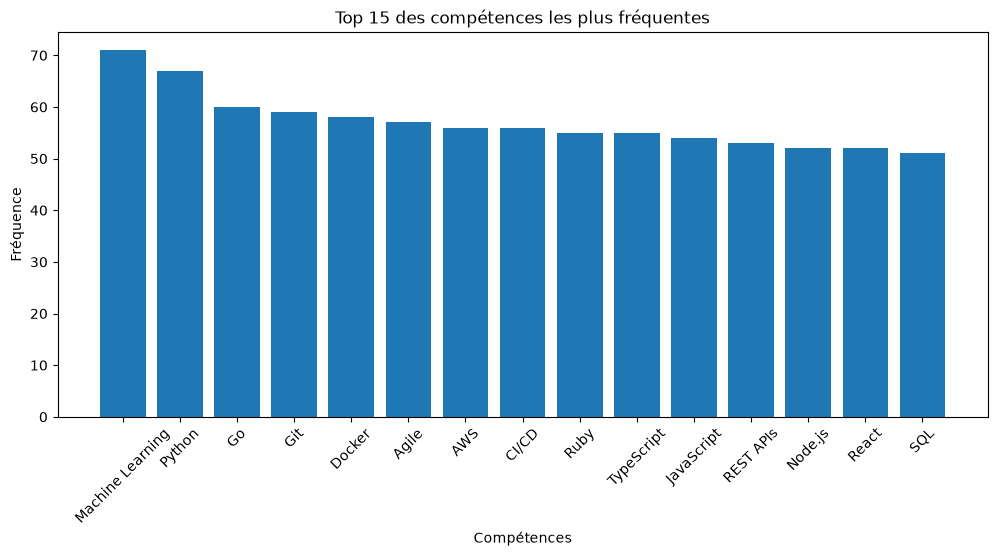

In [16]:
top_skills = skill_counts.most_common(15)

skills = [item[0] for item in top_skills]

counts = [item[1] for item in top_skills]

plt.figure(figsize=(12,5))

plt.bar(skills, counts)

plt.title("Top 15 des compétences les plus fréquentes")

plt.xlabel("Compétences")

plt.ylabel("Fréquence")

plt.xticks(rotation=45)

plt.show()

# Conclusion de l’analyse RAW

Les principales observations sont :

- Le dataset contient 250 offres d’emploi
- Certaines colonnes présentent des valeurs manquantes
- Aucun doublon n’a été détecté
- La colonne skills contient 19 compétences techniques uniques
- Les compétences les plus fréquentes sont liées au développement logiciel, au cloud et au machine learning

Ce diagnostic servira à construire la couche Silver dans laquelle les données seront nettoyées et standardisées.